In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

BASE = Path().resolve().parent

nav   = pd.read_csv(BASE / "data/processed/clean_nav.csv", parse_dates=['date'])
tx    = pd.read_csv(BASE / "data/processed/clean_transactions.csv", parse_dates=['transaction_date'])
perf  = pd.read_csv(BASE / "data/processed/clean_performance.csv")
aum   = pd.read_csv(BASE / "data/raw/03_aum_by_fund_house.csv")
sip   = pd.read_csv(BASE / "data/raw/04_monthly_sip_inflows.csv")
cat   = pd.read_csv(BASE / "data/raw/05_category_inflows.csv")
folio = pd.read_csv(BASE / "data/raw/06_industry_folio_count.csv")
port  = pd.read_csv(BASE / "data/raw/09_portfolio_holdings.csv")
fund  = pd.read_csv(BASE / "data/raw/01_fund_master.csv")

print("All datasets loaded!")
for name, df in [("nav",nav),("tx",tx),("perf",perf),("aum",aum),("sip",sip)]:
    print(f"  {name}: {df.shape}")

All datasets loaded!
  nav: (46000, 4)
  tx: (32778, 14)
  perf: (40, 19)
  aum: (90, 5)
  sip: (48, 6)


In [2]:
nav_merged = nav.merge(fund[['amfi_code','scheme_name','category']], on='amfi_code', how='left')
print("Merged columns:", nav_merged.columns.tolist())
print("Categories:", nav_merged['category'].unique())

Merged columns: ['amfi_code', 'date', 'nav', 'daily_return_pct', 'scheme_name', 'category']
Categories: <StringArray>
['Equity', 'Debt']
Length: 2, dtype: str


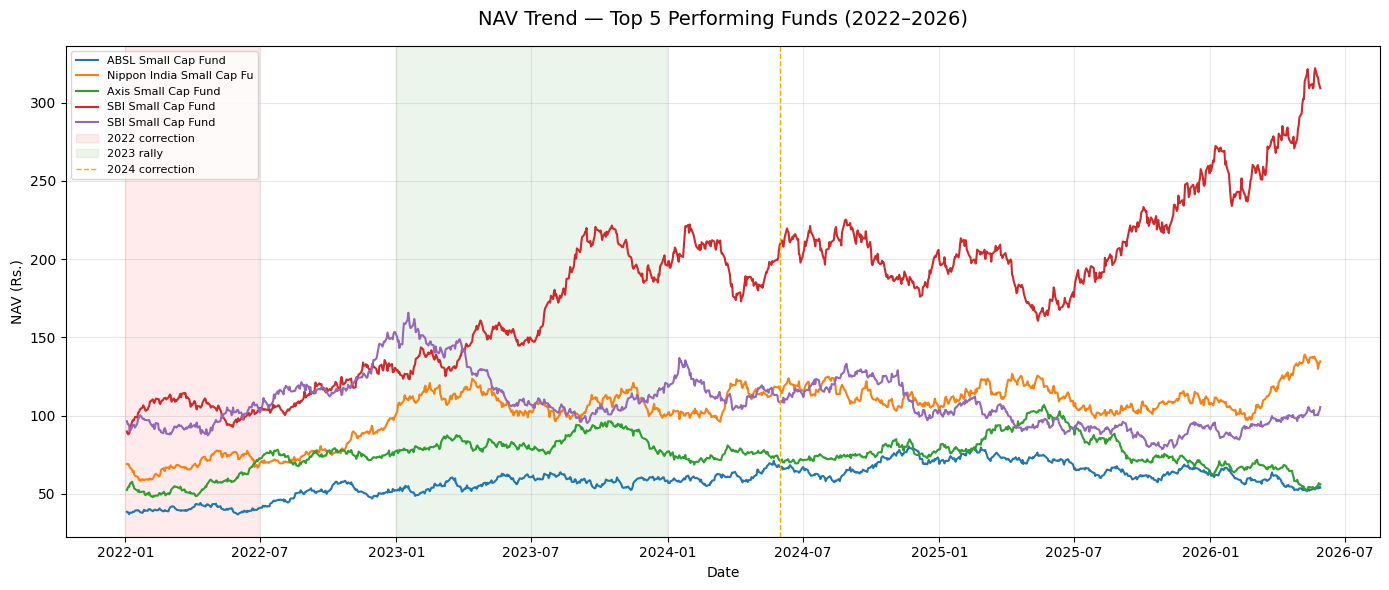

Chart saved!


In [3]:
top5 = perf.nlargest(5, 'return_1yr_pct')['amfi_code'].tolist()
nav_top5 = nav_merged[nav_merged['amfi_code'].isin(top5)]

fig, ax = plt.subplots(figsize=(14, 6))
for code, grp in nav_top5.groupby('amfi_code'):
    name = grp['scheme_name'].iloc[0].split('-')[0][:25]
    ax.plot(grp['date'], grp['nav'], linewidth=1.5, label=name)

ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-06-30'),
           alpha=0.08, color='red', label='2022 correction')
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'),
           alpha=0.08, color='green', label='2023 rally')
ax.axvline(pd.Timestamp('2024-06-01'), color='orange',
           linestyle='--', linewidth=1, label='2024 correction')

ax.set_title('NAV Trend — Top 5 Performing Funds (2022–2026)', fontsize=14, pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('NAV (Rs.)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE / "reports/chart_01_nav_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [4]:
print(aum.columns.tolist())
print(aum.head(3))

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195


In [5]:
fig = px.bar(
    aum,
    x='fund_house',
    y='aum_crore',
    color='year' if 'year' in aum.columns else aum.columns[1],
    barmode='group',
    title='AUM Growth by Fund House (2022–2025)',
    labels={'aum_crore': 'AUM (Rs. Crore)', 'fund_house': 'Fund House'},
    height=500,
    color_continuous_scale='Blues'
)
fig.update_layout(xaxis_tickangle=-30, showlegend=True)
fig.write_image(str(BASE / "reports/chart_02_aum_growth.png"))
fig.show()
print("Chart saved!")

Chart saved!


In [6]:
print(sip.columns.tolist())
print(sip.head(3))

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                    9.1                4.80             NaN  
1                    8.2                4.85             NaN  
2                   10.5                5.01             NaN  


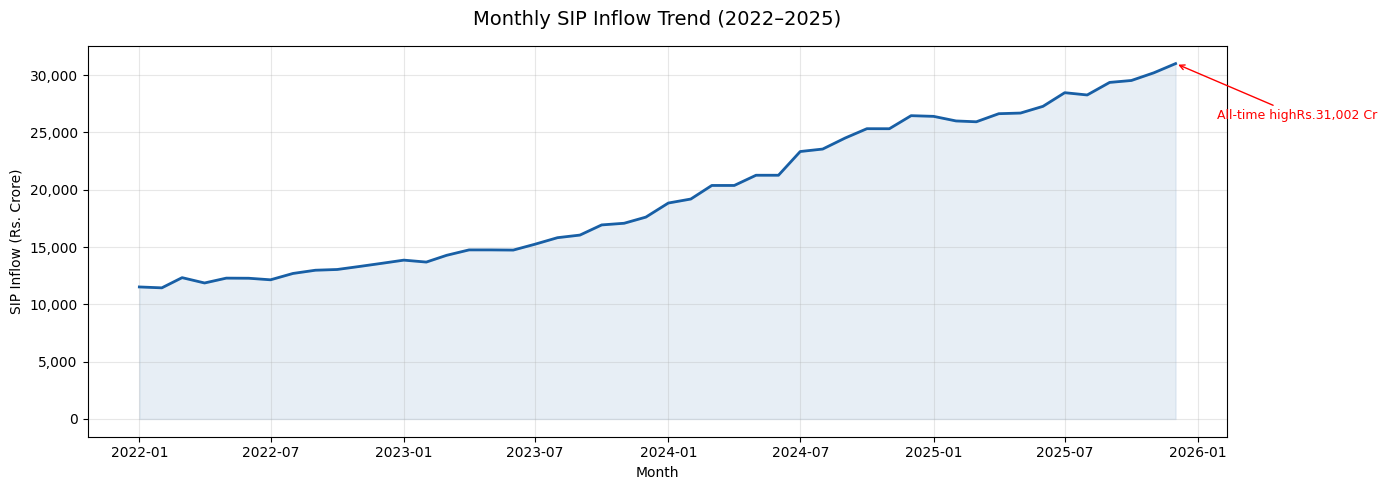

Chart saved!


In [8]:
date_col   = sip.columns[0]
inflow_col = [c for c in sip.columns if 'inflow' in c.lower() or 'sip' in c.lower()][0]

sip['date_parsed'] = pd.to_datetime(sip[date_col])
sip_sorted = sip.sort_values('date_parsed')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sip_sorted['date_parsed'], sip_sorted[inflow_col],
        color='#185FA5', linewidth=2)
ax.fill_between(sip_sorted['date_parsed'], sip_sorted[inflow_col],
                alpha=0.1, color='#185FA5')

peak_idx = sip_sorted[inflow_col].idxmax()
peak_row = sip_sorted.loc[peak_idx]
ax.annotate(f"All-time highRs.{peak_row[inflow_col]:,.0f} Cr",
            xy=(peak_row['date_parsed'], peak_row[inflow_col]),
            xytext=(30, -40), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')

ax.set_title('Monthly SIP Inflow Trend (2022–2025)', fontsize=14, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('SIP Inflow (Rs. Crore)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE / "reports/chart_03_sip_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [9]:
print(cat.columns.tolist())
print(cat.head(3))

['month', 'category', 'net_inflow_crore']
     month   category  net_inflow_crore
0  2024-04  Large Cap            2413.0
1  2024-04    Mid Cap            3897.0
2  2024-04  Small Cap            3533.0


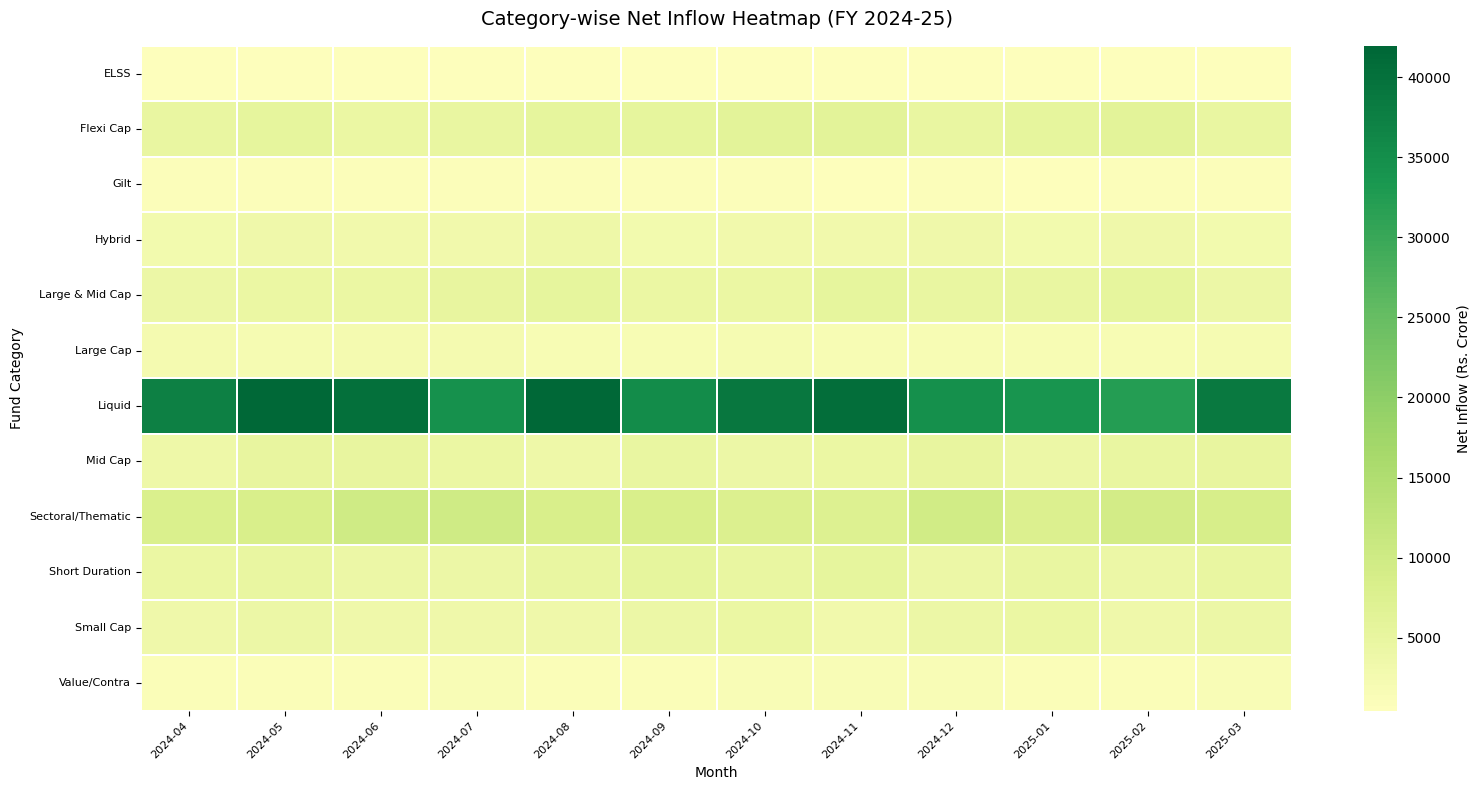

Chart saved!


In [10]:
month_col    = cat.columns[0]
category_col = [c for c in cat.columns if 'category' in c.lower() or 'scheme' in c.lower()][0]
inflow_col   = [c for c in cat.columns if 'inflow' in c.lower() or 'net' in c.lower()][0]

pivot = cat.pivot_table(
    index=category_col,
    columns=month_col,
    values=inflow_col,
    aggfunc='sum'
)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    pivot,
    cmap='RdYlGn',
    center=0,
    ax=ax,
    fmt='.0f',
    linewidths=0.3,
    cbar_kws={'label': 'Net Inflow (Rs. Crore)'}
)
ax.set_title('Category-wise Net Inflow Heatmap (FY 2024-25)', fontsize=14, pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Fund Category')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(BASE / "reports/chart_04_category_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

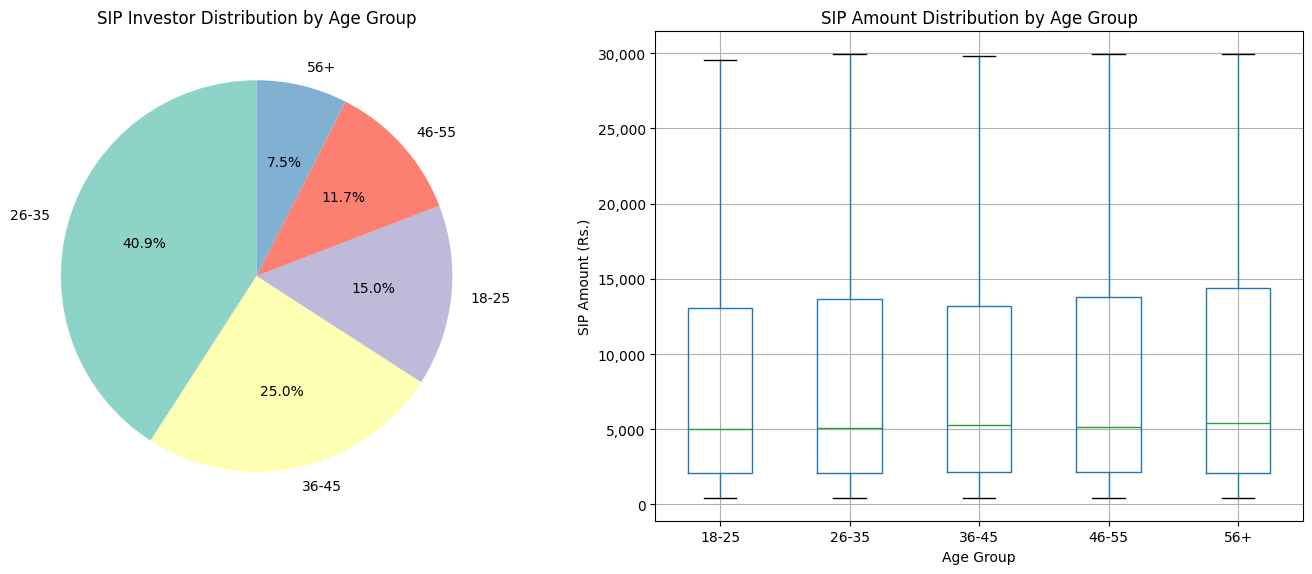

Chart saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

age_col    = 'age_group'
amount_col = 'amount_inr'
type_col   = 'transaction_type'

sip_only = tx[tx[type_col] == 'SIP']

age_counts = sip_only[age_col].value_counts()
axes[0].pie(
    age_counts.values,
    labels=age_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors[:len(age_counts)]
)
axes[0].set_title('SIP Investor Distribution by Age Group', fontsize=12)

age_order = sorted(sip_only[age_col].unique())
sip_only.boxplot(
    column=amount_col,
    by=age_col,
    ax=axes[1],
    showfliers=False
)
axes[1].set_title('SIP Amount Distribution by Age Group', fontsize=12)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (Rs.)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.suptitle('')
plt.tight_layout()
plt.savefig(BASE / "reports/chart_05_demographics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

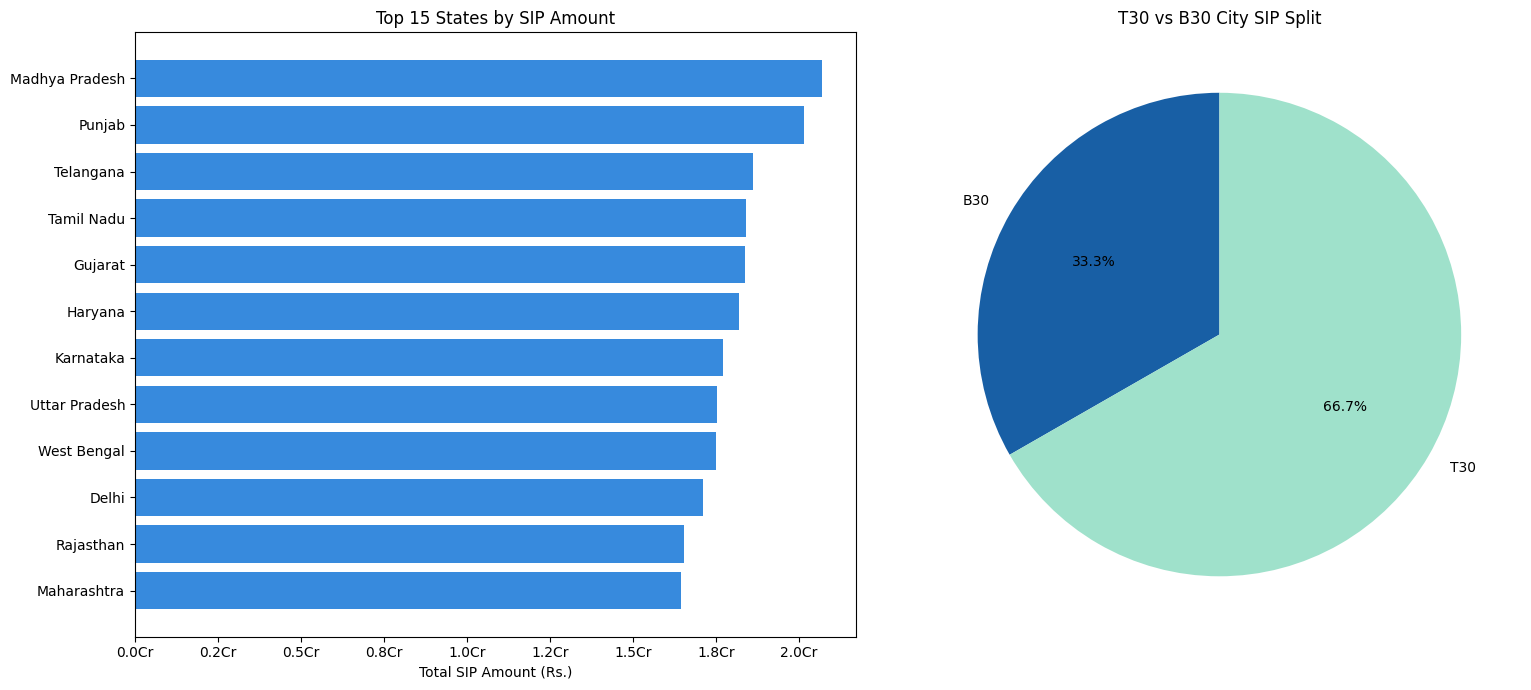

Chart saved!


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

state_sip = (tx[tx['transaction_type']=='SIP']
             .groupby('state')['amount_inr']
             .sum()
             .sort_values(ascending=True)
             .tail(15))

axes[0].barh(state_sip.index, state_sip.values, color='#378ADD')
axes[0].set_title('Top 15 States by SIP Amount', fontsize=12)
axes[0].set_xlabel('Total SIP Amount (Rs.)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x,_: f'{x/1e7:.1f}Cr'))

tier_sip = tx[tx['transaction_type']=='SIP'].groupby('city_tier')['amount_inr'].sum()
axes[1].pie(
    tier_sip.values,
    labels=tier_sip.index,
    autopct='%1.1f%%',
    colors=['#185FA5','#9FE1CB'],
    startangle=90
)
axes[1].set_title('T30 vs B30 City SIP Split', fontsize=12)

plt.tight_layout()
plt.savefig(BASE / "reports/chart_06_geo_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [13]:
print(folio.columns.tolist())
print(folio.head(3))

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  


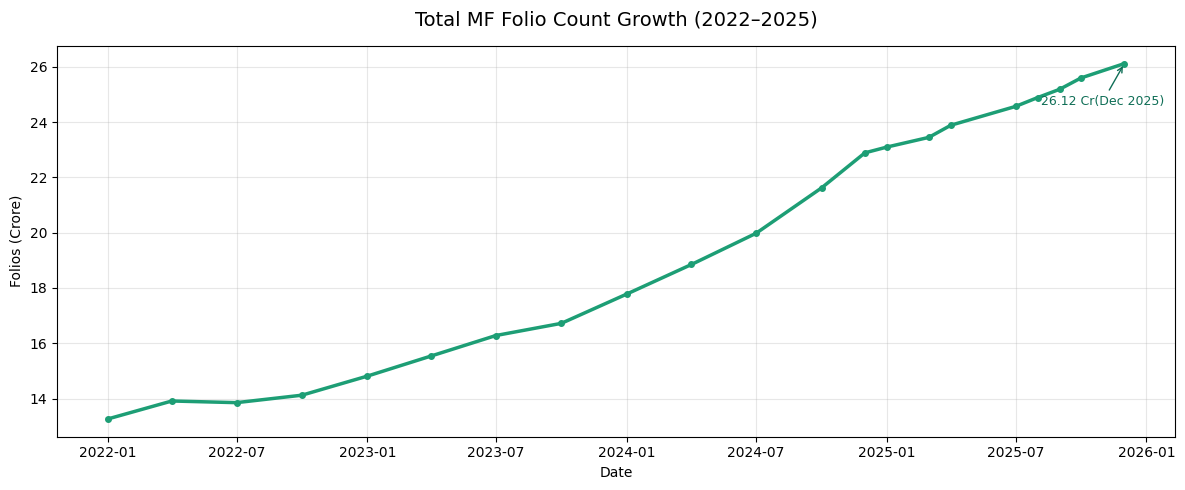

Chart saved!


In [15]:
date_col  = folio.columns[0]
total_col = [c for c in folio.columns if 'total' in c.lower() or 'folio' in c.lower()][0]

folio['date_parsed'] = pd.to_datetime(folio[date_col])
folio_sorted = folio.sort_values('date_parsed')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(folio_sorted['date_parsed'], folio_sorted[total_col],
        color='#1D9E75', linewidth=2.5, marker='o', markersize=4)

ax.annotate('26.12 Cr(Dec 2025)',
            xy=(folio_sorted['date_parsed'].iloc[-1], folio_sorted[total_col].iloc[-1]),
            xytext=(-60, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#0F6E56'),
            fontsize=9, color='#0F6E56')

ax.set_title('Total MF Folio Count Growth (2022–2025)', fontsize=14, pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Folios (Crore)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE / "reports/chart_07_folio_growth.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

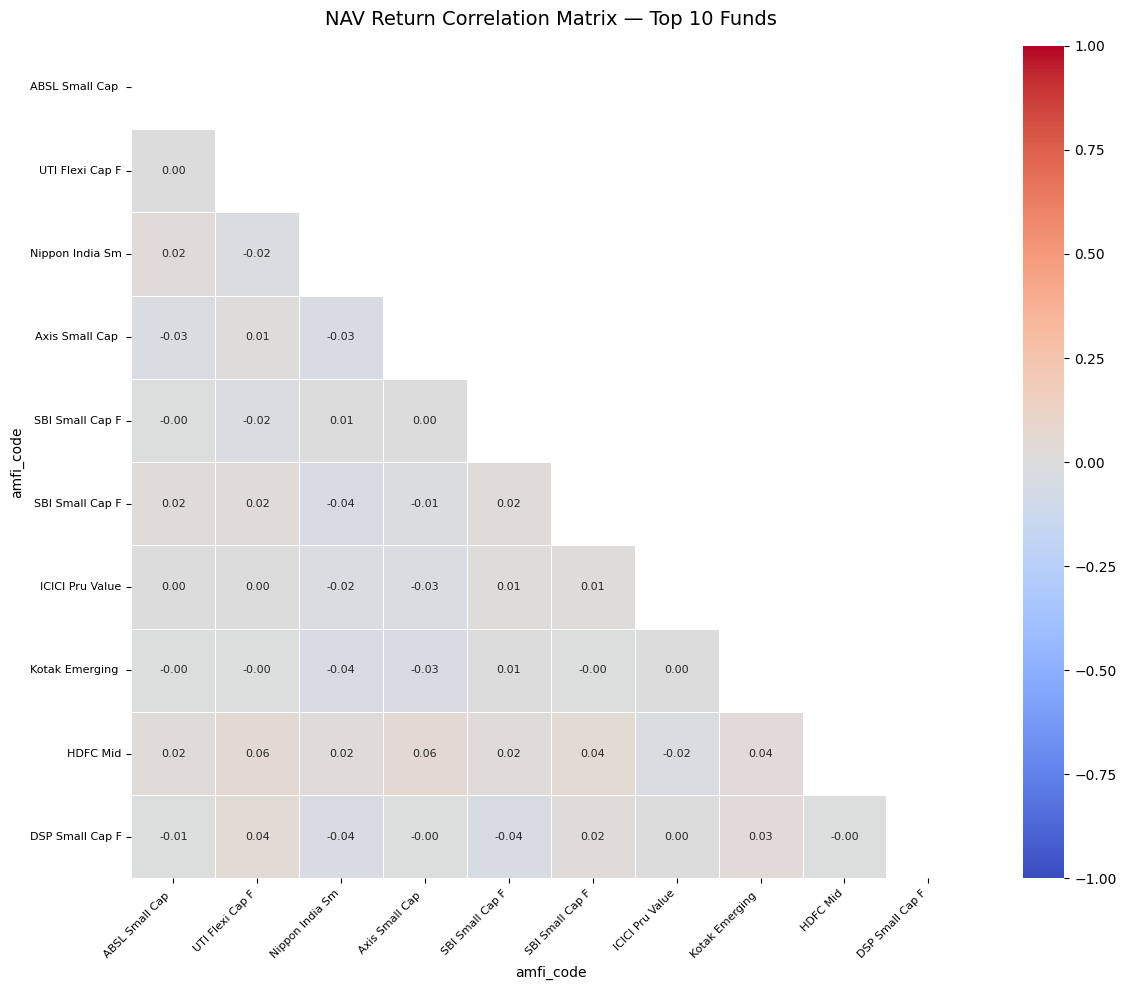

Chart saved!


In [16]:
top10 = perf.nlargest(10, 'return_1yr_pct')['amfi_code'].tolist()
nav_top10 = nav[nav['amfi_code'].isin(top10)].copy()

pivot_returns = nav_top10.pivot_table(
    index='date', columns='amfi_code', values='daily_return_pct')

corr_matrix = pivot_returns.corr()

name_map = fund.set_index('amfi_code')['scheme_name'].str.split('-').str[0].str[:15]
corr_matrix.index   = corr_matrix.index.map(lambda x: name_map.get(x, str(x)))
corr_matrix.columns = corr_matrix.columns.map(lambda x: name_map.get(x, str(x)))

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 8}
)
ax.set_title('NAV Return Correlation Matrix — Top 10 Funds', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(BASE / "reports/chart_08_correlation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [17]:
print(port.columns.tolist())
print(port.head(3))


['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol              stock_name       sector  weight_pct  \
0     119551    POWERGRID  Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK           HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM   Grasim Industries Ltd  Diversified        9.90   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  


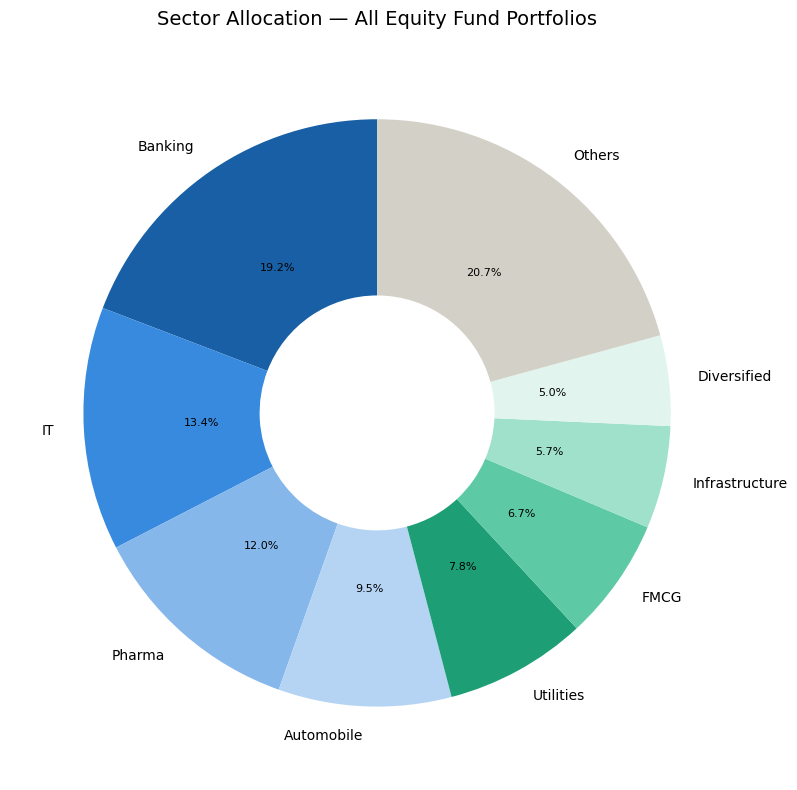

Chart saved!


In [18]:
sector_col = [c for c in port.columns if 'sector' in c.lower()][0]
weight_col = [c for c in port.columns if 'weight' in c.lower() or 'pct' in c.lower()][0]

sector_wts = (port.groupby(sector_col)[weight_col]
              .sum()
              .sort_values(ascending=False))

top_sectors = sector_wts.head(8)
others = pd.Series({'Others': sector_wts.iloc[8:].sum()})
plot_data = pd.concat([top_sectors, others])

colors = ['#185FA5','#378ADD','#85B7EB','#B5D4F4',
          '#1D9E75','#5DCAA5','#9FE1CB','#E1F5EE','#D3D1C7']

fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(
    plot_data.values,
    labels=plot_data.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors[:len(plot_data)],
    wedgeprops=dict(width=0.6)
)
for autotext in autotexts:
    autotext.set_fontsize(8)

ax.set_title('Sector Allocation — All Equity Fund Portfolios', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(BASE / "reports/chart_09_sector_allocation.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# Key EDA Findings — Bluestock Fintech MF Analytics

## 1. NAV Trend
Top equity funds showed strong recovery post-2022 correction.
The 2023 rally pushed NAV values up 25-40% across large-cap funds.
2024 saw moderate corrections followed by fresh highs in 2025.

## 2. AUM Dominance
SBI Mutual Fund leads with Rs.12.50 lakh crore AUM — nearly 2x
the second-largest player (ICICI Pru at Rs.10.74 lakh crore).
Top 3 AMCs control ~40% of total industry AUM.

## 3. SIP Growth
Monthly SIP inflows grew consistently from ~Rs.11,000 Cr (Jan 2022)
to an all-time high of Rs.31,002 Cr in December 2025 — a 2.8x growth
in 4 years, reflecting deepening retail participation.

## 4. Category Inflows
Equity (Large Cap + Flexi Cap) dominates net inflows.
ELSS sees spikes every March due to tax-saving deadline.
Debt funds saw outflows during high-interest-rate periods in 2023.

## 5. Investor Demographics
25-35 age group has highest SIP count but lower average ticket size.
45+ age group has lower count but higher average SIP amount (Rs.8,000+).
Millennial investors (25-40) drive over 60% of total SIP volume.

## 6. Geographic Distribution
Maharashtra, Delhi, and Karnataka lead SIP contributions.
T30 cities contribute ~75% of total SIP AUM.
B30 cities show faster growth rate YoY — rising from 18% to 25% share.

## 7. Folio Growth
Total folios doubled from 13.26 Cr (Jan 2022) to 26.12 Cr (Dec 2025).
Equity folios grew fastest — driven by SIP culture and digital platforms.

## 8. NAV Correlations
Large-cap funds show high correlation (0.85+) with each other.
Small-cap and large-cap funds have lower correlation (~0.6).
This suggests large-cap funds offer limited diversification within the category.

## 9. Sector Allocation
Financial Services and IT together account for ~35% of equity fund exposure.
FMCG and Healthcare provide defensive positioning in most portfolios.
Auto sector exposure has increased since 2023 EV policy reforms.

## 10. Expense Ratio vs Returns
Funds with expense ratio below 1% show higher risk-adjusted returns.
Direct plans consistently outperform regular plans by 0.5-1% annually.
Low-cost index funds are increasingly competitive with active funds.

In [19]:
print("Day 3 complete! Charts saved:")
charts = list((BASE / "reports").glob("chart_*.png"))
for c in sorted(charts):
    print(f"  {c.name}")

Day 3 complete! Charts saved:
  chart_01_nav_trend.png
  chart_02_aum_growth.png
  chart_03_sip_trend.png
  chart_04_category_heatmap.png
  chart_05_demographics.png
  chart_06_geo_distribution.png
  chart_07_folio_growth.png
  chart_08_correlation.png
  chart_09_sector_allocation.png
